In [35]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# DEPENDENCY: install the xlrd pip package to be able to read excel using pandas (pip install xlrd)
import warnings
warnings.filterwarnings('ignore')

import lib.databaseGateway as db
import lib.configurationProvider as config
import lib.rectangles as rect

In [36]:
annotations = db.get_recall_annotations()
for a in annotations:
    rect.normalize_recall_annotation(a)
annotations[0]

{'id': '5ec14b142a92684125500c16',
 'bucket': '0',
 'annotation_order': 'GF',
 'bucket_order': 'STD',
 'annotation': {'prolificId': '5ec14b142a92684125500c16',
  'seed': 0,
  'annotationOrder': 'global_first',
  'roundSequence': 'standard',
  'studyStart': '2026-02-15T15:14:50.703Z',
  'instructionTimings': [{'page': 0, 'duration': 19679},
   {'page': 1, 'duration': 7863},
   {'page': 2, 'duration': 2129},
   {'page': 'adjustment', 'duration': 7951}],
  'rounds': [{'roundId': 'Maldives_Dec2015_0002/Maldives_Dec2015_0002_72.jpg',
    'roundStart': '2026-02-15T15:14:50.707Z',
    'imageDuration': 10001,
    'distractorType': 'visual-search',
    'distractorAnswer': {'instructionDuration': 12275,
     'distractorDuration': 3388,
     'correct': True,
     'response': 'f',
     'target_present': False,
     'total': 1,
     'trials': [{'rt': 3388, 'response': 'f', 'correct': True}]},
    'annotation1Duration': 14868,
    'annotation2Duration': 15198,
    'initialRect': [29, 95, 563, 290],


In [37]:
def get_annotation_stats(annotation):
    stats = {
        "id": annotation["id"],
        "distractors": 0,
        "total_time": 0,
        "annotationOrder": annotation["annotation"]["annotationOrder"],
        "roundSequence": annotation["annotation"]["roundSequence"],
        "rounds": []
    }
    for instruction in annotation["annotation"]["instructionTimings"]:
        stats["total_time"] += instruction["duration"]

    for round in annotation["annotation"]["rounds"]:
        round_time = round["imageDuration"]
        round_time += round["annotation1Duration"]
        round_time += round["annotation2Duration"]
        round_time += round["adjustmentDuration"]
        round_time += round["distractorAnswer"]["instructionDuration"]
        round_time += round["distractorAnswer"]["distractorDuration"]
        round_stats = {
            "initialRect": round["initialRect"],
            "finalRect": round["finalRect"],
            "round_time": round_time,
            "globalDesc": round["globalDesc"],
            "objectDesc": round["objectDesc"],
        }
        if round["distractorAnswer"]["correct"] == True:
            stats["distractors"] += 1
        stats["total_time"] += round_time
        stats["rounds"].append(round_stats)
    return stats

annotation_stats = [get_annotation_stats(a) for a in annotations]
annotation_stats[0]



{'id': '5ec14b142a92684125500c16',
 'distractors': 6,
 'total_time': 508739,
 'annotationOrder': 'global_first',
 'roundSequence': 'standard',
 'rounds': [{'initialRect': [29, 95, 563, 290],
   'finalRect': [0, 43, 541, 354],
   'round_time': 64805,
   'globalDesc': 'a diver swimming over a whale in deep water',
   'objectDesc': 'said diver with a whale underneath him'},
  {'initialRect': [55, 150, 554, 300],
   'finalRect': [151, 62, 656, 267],
   'round_time': 59246,
   'globalDesc': 'a flatfish having a swim next to coral',
   'objectDesc': 'a flatfish'},
  {'initialRect': [41, 55, 149, 122],
   'finalRect': [91, 22, 181, 88],
   'round_time': 88486,
   'globalDesc': 'bad quality picture of deep waters, a coral reef and some small fish',
   'objectDesc': 'small, fluorescent fish'},
  {'initialRect': [21, 66, 234, 160],
   'finalRect': [0, 0, 189, 105],
   'round_time': 69110,
   'globalDesc': 'a wreck on the bottom of the ocean/sea and a fish swimming next to it',
   'objectDesc': '

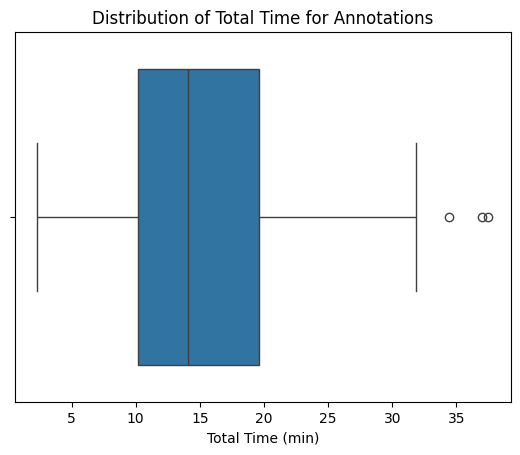

In [38]:
# create a box plot of total_time
sns.boxplot(x=[a["total_time"] / 1000 / 60 for a in annotation_stats])
plt.xlabel("Total Time (min)")
plt.title("Distribution of Total Time for Annotations")
plt.show()

Text(0.5, 1.0, 'Distribution of Number of Distractors for Annotations')

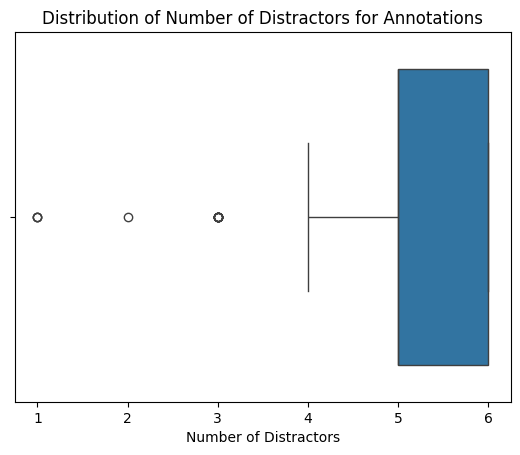

In [39]:
# create a box plot of distractors
sns.boxplot(x=[a["distractors"] for a in annotation_stats])
plt.xlabel("Number of Distractors")
plt.title("Distribution of Number of Distractors for Annotations")

In [40]:
print("Not enough distractors:")
not_enough_distractors = [a["id"] for a in annotation_stats if a["distractors"] < 4]
for d in not_enough_distractors:
    print(d)

Not enough distractors:
667ecb3f5e0218c7c740aa2f
60c076e9ce50e01ef77bdcdb
678d322df1def0ae54a2e445
66ceb03e08f588238d4ce3ae
66c3030545e4f44aebf477b7
67529d0aecb73bfe140d521f
612adba08b8235b31539c704
616c2e23cdae23ccf15ae162
67545c44724e5a9bdfa96ab4
6739ff11a2162a865c36fa64
584823aed2be990001174e56
676d220cd6e7101ccba18ba5
611fbfae3ce6f9dfaa946f69
6658d02b830a00e979619fb8


In [41]:
# filter out annotations with less than 4 distractors
filtered_stats = [a for a in annotation_stats if a["distractors"] >= 4]

print(len(annotation_stats))
print(len(filtered_stats))

# filter out the lowest and highest 5 percentiles of total_time
total_time_values = [a["total_time"] for a in filtered_stats]
lower_bound = np.percentile(total_time_values, 5)
upper_bound = np.percentile(total_time_values, 95)
filtered_stats = [a for a in filtered_stats if lower_bound <= a["total_time"] <= upper_bound]



print(len(annotation_stats))
print(len(filtered_stats))

185
171
185
153


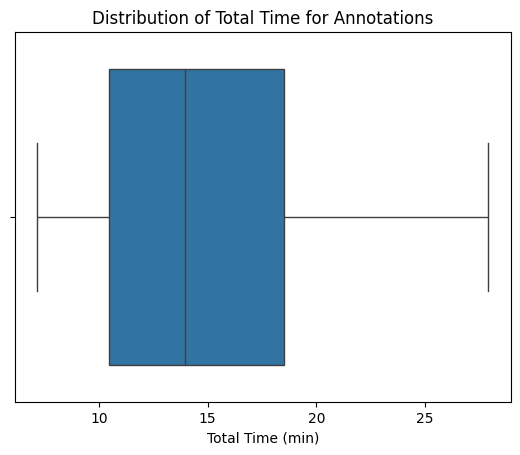

In [42]:
# create a box plot of total_time
sns.boxplot(x=[a["total_time"] / 1000 / 60 for a in filtered_stats])
plt.xlabel("Total Time (min)")
plt.title("Distribution of Total Time for Annotations")
plt.show()

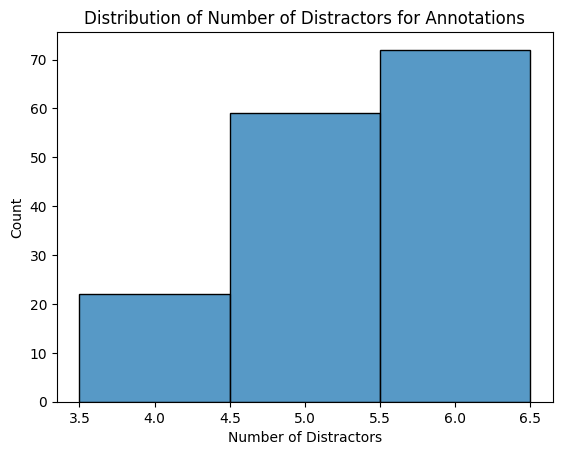

In [43]:
# create histogram of distractors with whole numbers in x-axis
sns.histplot(x=[a["distractors"] for a in filtered_stats], bins=range(0, 11), discrete=True)
plt.xlabel("Number of Distractors")
plt.title("Distribution of Number of Distractors for Annotations")
plt.show()

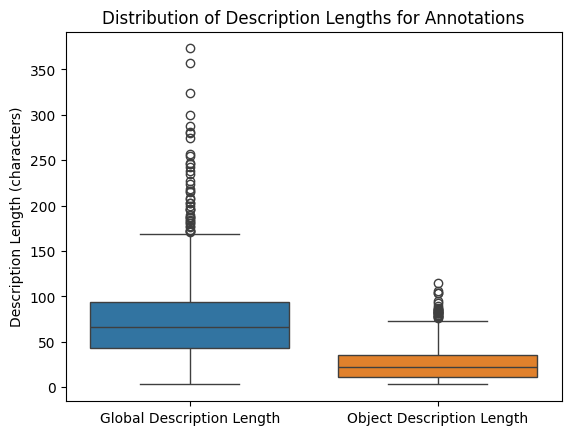

In [44]:
# create box plots of global and object description lengths
global_desc_lengths = []
object_desc_lengths = []
for stats in filtered_stats:
    for round in stats["rounds"]:
        global_desc_lengths.append(len(round["globalDesc"]))
        object_desc_lengths.append(len(round["objectDesc"]))
sns.boxplot(data=[global_desc_lengths, object_desc_lengths])
plt.xticks([0, 1], ["Global Description Length", "Object Description Length"])
plt.ylabel("Description Length (characters)")
plt.title("Distribution of Description Lengths for Annotations")
plt.show()

Shift mean: 4.0360 (Expected ~0)
Shift std (shift_factor): 46.9969
Ratio mean: 0.9817 (Expected ~1)
Ratio std (perturbation_factor - approx): 0.5147


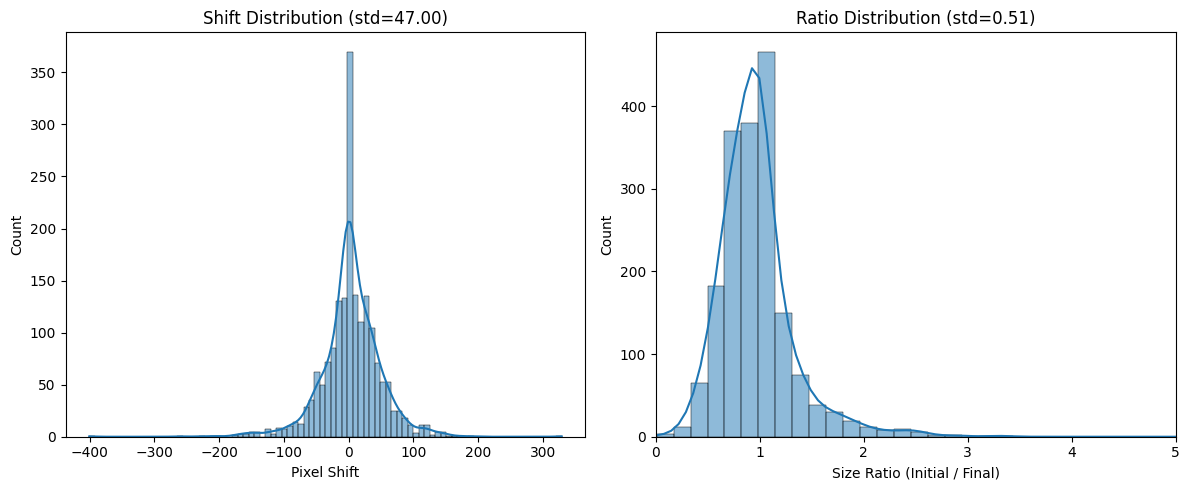

In [45]:
def get_wh(rect):
    x1, y1, x2, y2 = rect
    return (abs(x2 - x1), abs(y2 - y1))

def get_center(rect):
    x1, y1, x2, y2 = rect
    # Ensure float division
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

shifts_x = []
shifts_y = []
ratios_w = []
ratios_h = []

# Use filtered_stats instead of all annotations
# filtered_stats contains dictionaries with "rects" list
# e.g., stats["rects"].append({"initialRect": ..., "finalRect": ...})

for stats in filtered_stats:
    for round in stats["rounds"]:
        initial = round["initialRect"]
        final = round["finalRect"]

        w_f, h_f = get_wh(final)
        w_i, h_i = get_wh(initial)
        # Avoid division by zero
        if w_f == 0 or h_f == 0:
            continue

        c_ix, c_iy = get_center(initial)
        c_fx, c_fy = get_center(final)
        
        # Shifts: simply the difference in centers
        dx = c_ix - c_fx
        dy = c_iy - c_fy
        shifts_x.append(dx)
        shifts_y.append(dy)

        # Ratios: initial / final
        # If final is ground truth, initial is perturbed version of it.
        # But wait, usually we want Ratio = Perturbed / Original.
        # Here Initial ~ Perturbed, Final ~ Original.
        # So Ratio = Initial / Final
        
        r_w = w_i / w_f
        r_h = h_i / h_f
        ratios_w.append(r_w)
        ratios_h.append(r_h)

shifts = np.array(shifts_x + shifts_y)
scalings = np.array(ratios_w + ratios_h)

if len(shifts) > 0:
    shift_mean = np.mean(shifts)
    shift_std = np.std(shifts)
    
    ratio_mean = np.mean(scalings)
    ratio_std = np.std(scalings)

    print(f"Shift mean: {shift_mean:.4f} (Expected ~0)")
    print(f"Shift std (shift_factor): {shift_std:.4f}")
    
    print(f"Ratio mean: {ratio_mean:.4f} (Expected ~1)")
    print(f"Ratio std (perturbation_factor - approx): {ratio_std:.4f}")

    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(shifts, kde=True, ax=axes[0])
    axes[0].set_title(f'Shift Distribution (std={shift_std:.2f})')
    axes[0].set_xlabel('Pixel Shift')

    sns.histplot(scalings, kde=True, ax=axes[1])
    axes[1].set_title(f'Ratio Distribution (std={ratio_std:.2f})')
    axes[1].set_xlabel('Size Ratio (Initial / Final)')
    axes[1].set_xlim(0, 5) # Reasonable range

    plt.tight_layout()
    plt.show()
else:
    print("No data after filtering.")

Simulating with shift_factor=46.9969, pertubation_factor=0.5147
------------------------------
Simulation Results:
Sim Shift mean: -5.0340 (Expected ~0)
Sim Shift std: 49.2915 (Expected ~46.9969)
Sim Ratio mean: 1.0152 (Expected ~1)
Sim Ratio std: 0.4980 (Expected ~0.5147)
------------------------------
Real Data Stats (Filtered):
Ratio Min: 0.0055
Ratio Max: 14.0625
Ratio Median: 0.9459
Ratio 95th Percentile: 1.6533


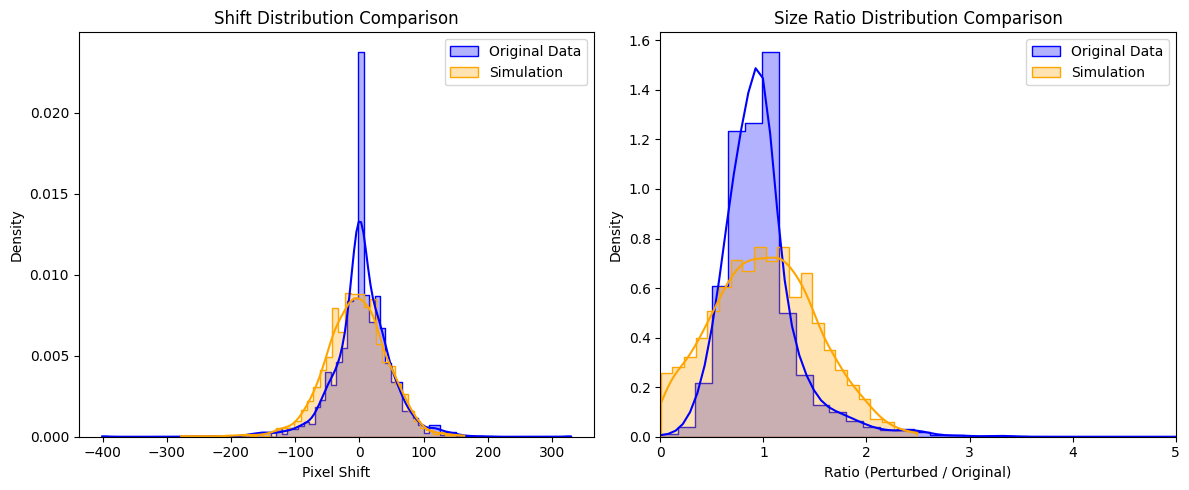

In [46]:
# Verification: Simulate perturbations using estimated parameters from FILTERED data
sim_shifts_x = []
sim_shifts_y = []
sim_ratios_w = []
sim_ratios_h = []

# Frame dimensions from config
frame_width = config.frame_width
frame_height = config.frame_height

# Parameters estimated from data
estimated_pertubation_factor = ratio_std
estimated_shift_factor = shift_std

print(f"Simulating with shift_factor={estimated_shift_factor:.4f}, pertubation_factor={estimated_pertubation_factor:.4f}")

# Use filtered_stats for simulation source too
for stats in filtered_stats:
    for round in stats["rounds"]:
        final = round["finalRect"]
        
        # Apply perturbation using the estimated parameters
        # pertube_rect_multi(rect, pertubation_factor, shift_factor, frame_width, frame_height)
        perturbed = rect.pertube_rect_multi(final, estimated_pertubation_factor, estimated_shift_factor, frame_width, frame_height)
        
        # Calculate resulting shift and ratio
        w_f, h_f = get_wh(final)
        w_p, h_p = get_wh(perturbed)
        
        if w_f == 0 or h_f == 0:
            continue

        c_fx, c_fy = get_center(final)
        c_px, c_py = get_center(perturbed)
        
        # Shifts
        dx = c_px - c_fx
        dy = c_py - c_fy
        sim_shifts_x.append(dx)
        sim_shifts_y.append(dy)

        # Scaling
        s_x = w_p / w_f
        s_y = h_p / h_f
        sim_ratios_w.append(s_x)
        sim_ratios_h.append(s_y)

sim_shifts = np.array(sim_shifts_x + sim_shifts_y)
sim_ratios = np.array(sim_ratios_w + sim_ratios_h)

sim_shift_mean = np.mean(sim_shifts)
sim_shift_std = np.std(sim_shifts)

sim_ratio_mean = np.mean(sim_ratios)
sim_ratio_std = np.std(sim_ratios)

print("-" * 30)
print("Simulation Results:")
print(f"Sim Shift mean: {sim_shift_mean:.4f} (Expected ~0)")
print(f"Sim Shift std: {sim_shift_std:.4f} (Expected ~{estimated_shift_factor:.4f})")
print(f"Sim Ratio mean: {sim_ratio_mean:.4f} (Expected ~1)")
print(f"Sim Ratio std: {sim_ratio_std:.4f} (Expected ~{estimated_pertubation_factor:.4f})")

# Additional stats
print("-" * 30)
print("Real Data Stats (Filtered):")
print(f"Ratio Min: {np.min(scalings):.4f}")
print(f"Ratio Max: {np.max(scalings):.4f}")
print(f"Ratio Median: {np.median(scalings):.4f}")
print(f"Ratio 95th Percentile: {np.percentile(scalings, 95):.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Use the same range explicitly to compare distributions
shift_range = (min(np.min(shifts), np.min(sim_shifts)), max(np.max(shifts), np.max(sim_shifts)))
ratio_range = (0, 5) # Focus on relevant positive ratio range

# Set alpha to be more transparent
sns.histplot(shifts, kde=True, ax=axes[0], stat="density", label='Original Data', color='blue', alpha=0.3, element="step")
sns.histplot(sim_shifts, kde=True, ax=axes[0], stat="density", label='Simulation', color='orange', alpha=0.3, element="step")
axes[0].set_title('Shift Distribution Comparison')
axes[0].set_xlabel('Pixel Shift')
axes[0].legend()

sns.histplot(scalings, kde=True, ax=axes[1], stat="density", label='Original Data', color='blue', alpha=0.3, element="step")
sns.histplot(sim_ratios, kde=True, ax=axes[1], stat="density", label='Simulation', color='orange', alpha=0.3, element="step")
axes[1].set_title('Size Ratio Distribution Comparison')
axes[1].set_xlabel('Ratio (Perturbed / Original)')
axes[1].set_xlim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

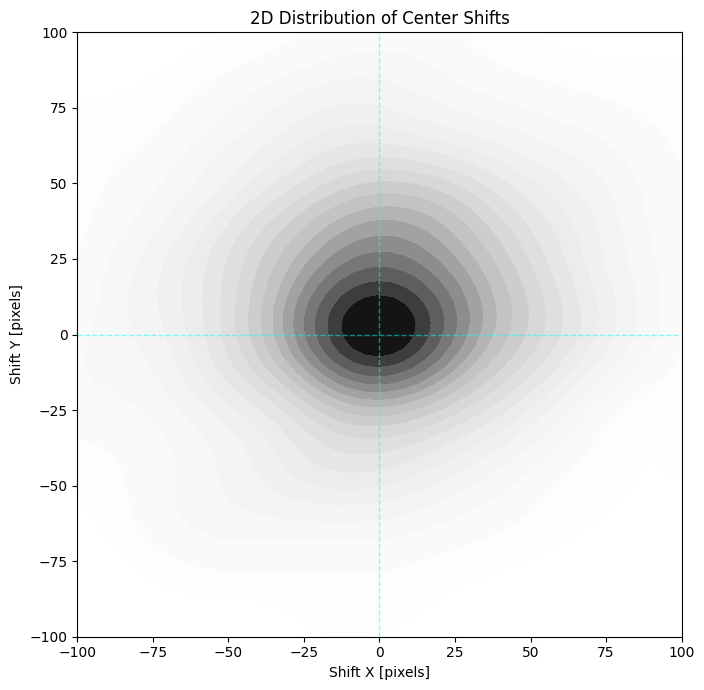

In [47]:
# Plot 2D distribution of Shift errors (Heatmap)
fig, ax = plt.subplots(figsize=(8, 7))

# Create a 2D density plot (KDE) which approximates the 2D Gaussian
# 'thresh' controls the lowest contour level to draw
# 'levels' controls the number of contour levels
# cmap="Greys" ensures 0 density is white and max density is black
sns.kdeplot(x=shifts_x, y=shifts_y, fill=True, cmap="Greys", thresh=0.01, levels=20, ax=ax)

# Add (0,0) marker
ax.axhline(0, color='cyan', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0, color='cyan', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)

ax.set_title("2D Distribution of Center Shifts")
ax.set_xlabel("Shift X [pixels]")
ax.set_ylabel("Shift Y [pixels]")
ax.set_aspect('equal')

# Add text for stats
# ax.text(0.05, 0.95, f"Std X: {np.std(shifts_x):.2f}\nStd Y: {np.std(shifts_y):.2f}", 
#         transform=ax.transAxes, color='black', 
#         bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

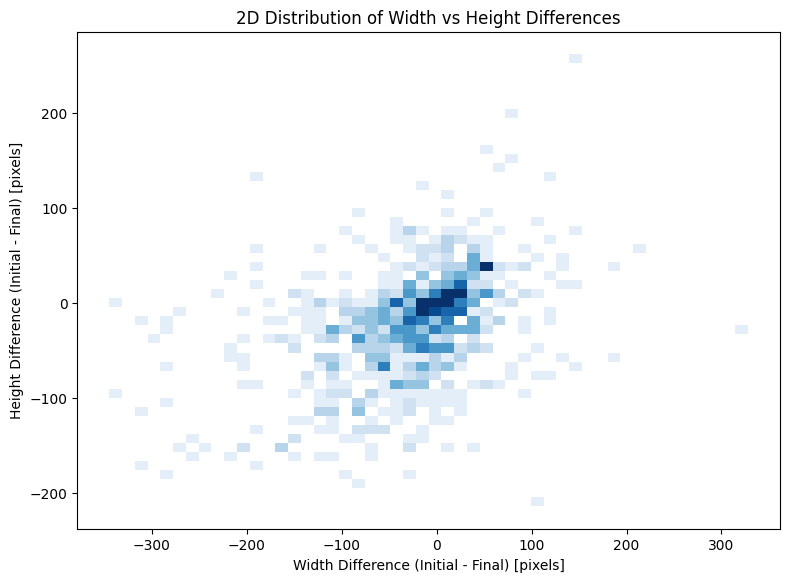

In [48]:
# Plot 2D distribution of Pixel Dimensional Differences (Heatmap)
# (Width Difference vs Height Difference)

width_diffs = []
height_diffs = []

for stats in filtered_stats:
    # Handle different possible keys for rounds data
    if "rects" in stats:
        rounds_data = stats["rects"]
    elif "rounds" in stats:
        rounds_data = stats["rounds"]
    else:
        continue

    for r in rounds_data:
        if "initialRect" not in r or "finalRect" not in r:
            continue
        
        initial = r["initialRect"]
        final = r["finalRect"]

        w_f, h_f = get_wh(final)
        w_i, h_i = get_wh(initial)
        
        if w_f == 0 or h_f == 0:
            continue
            
        width_diffs.append(w_i - w_f)
        height_diffs.append(h_i - h_f)

if len(width_diffs) > 0:
    fig, ax = plt.subplots(figsize=(8, 7))

    # create 2D square bins for the heatmap
    sns.histplot(x=width_diffs, y=height_diffs, bins=50, pmax=0.8, cmap="Blues", ax=ax)
    ax.set_title("2D Distribution of Width vs Height Differences")
    ax.set_xlabel("Width Difference (Initial - Final) [pixels]")
    ax.set_ylabel("Height Difference (Initial - Final) [pixels]")
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
else:
    print("No valid width/height differences found.")

Mean: [-24.03707743 -20.7131952 ]
Covariance Matrix:
[[5192.88727005 1619.06959756]
 [1619.06959756 2855.29647417]]
Principal Component 1: [-0.89031321 -0.45534864], Variance: 6020.96
Principal Component 2: [ 0.45534864 -0.89031321], Variance: 2027.23
Rotation Angle: -152.91 degrees


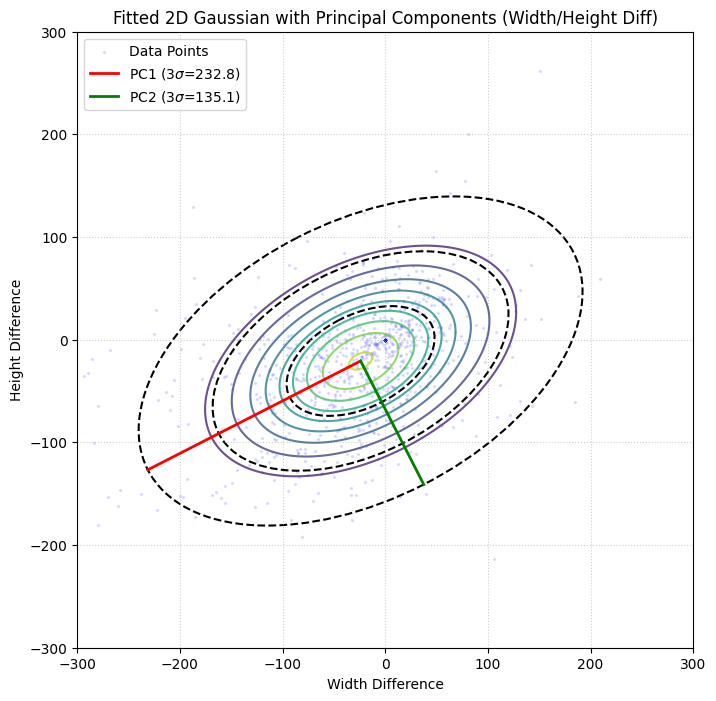

In [49]:
from scipy.stats import multivariate_normal
import matplotlib.patches as patches

# Fit a 2D Gaussian to the data (Dimensional Diff)
# Data: Width Difference vs Height Difference
data = np.vstack([width_diffs, height_diffs]).T

# Calculate mean and covariance
mean = np.mean(data, axis=0)
cov = np.cov(data, rowvar=False)

print(f"Mean: {mean}")
print(f"Covariance Matrix:\n{cov}")

# Use PCA (via Eigendecomposition of Covariance Matrix) to find orientation
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort eigenvalues and eigenvectors in descending order
order = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Angle of the first principal component
angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

print(f"Principal Component 1: {eigenvectors[:, 0]}, Variance: {eigenvalues[0]:.2f}")
print(f"Principal Component 2: {eigenvectors[:, 1]}, Variance: {eigenvalues[1]:.2f}")
print(f"Rotation Angle: {angle:.2f} degrees")

# Plot the data and the fitted Gaussian (as ellipses)
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot of raw data (with some transparency)
ax.scatter(data[:, 0], data[:, 1], alpha=0.1, s=2, color='blue', label='Data Points')

limit = 300
# Create a grid for contour plot
x, y = np.mgrid[-limit:limit:.5, -limit:limit:.5]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)

# Plot probability density contours
ax.contour(x, y, rv.pdf(pos), levels=10, cmap="viridis", alpha=0.8)

# Draw Principal Axes
# std_dev = sqrt(eigenvalue)
std_devs = np.sqrt(eigenvalues)
scale_factor = 3 # 3 standard deviations

# PC1
ax.plot([mean[0], mean[0] + scale_factor * std_devs[0] * eigenvectors[0, 0]],
        [mean[1], mean[1] + scale_factor * std_devs[0] * eigenvectors[1, 0]],
        color='red', lw=2, label=f'PC1 (3$\sigma$={scale_factor * std_devs[0]:.1f})')

# PC2
ax.plot([mean[0], mean[0] + scale_factor * std_devs[1] * eigenvectors[0, 1]],
        [mean[1], mean[1] + scale_factor * std_devs[1] * eigenvectors[1, 1]],
        color='green', lw=2, label=f'PC2 (3$\sigma$={scale_factor * std_devs[1]:.1f})')


# Add Ellipses for 1, 2, 3 std deviations
for n_std in [1, 2, 3]:
    ellipse = patches.Ellipse(xy=mean, width=2 * n_std * std_devs[0], height=2 * n_std * std_devs[1],
                              angle=angle, edgecolor='black', fc='None', lw=1.5, linestyle='--')
    ax.add_patch(ellipse)
    # Label the ellipse
    # ax.text(mean[0] + n_std * std_devs[0] * eigenvectors[0, 0], 
    #         mean[1] + n_std * std_devs[1] * eigenvectors[1, 0], 
    #         f'{n_std}$\sigma$', color='black')

ax.set_title("Fitted 2D Gaussian with Principal Components (Width/Height Diff)")
ax.set_xlabel("Width Difference")
ax.set_ylabel("Height Difference")
ax.set_aspect('equal')
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.show()

Simulating using 2D Gaussian Covariance (Shift = 0)
Generated 917 simulated samples.


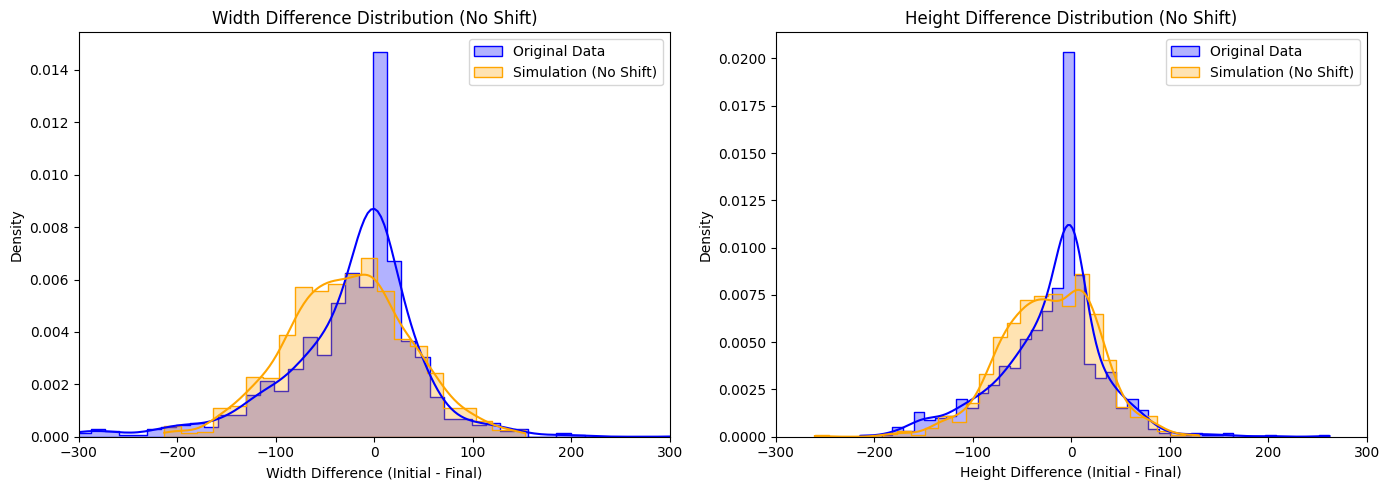

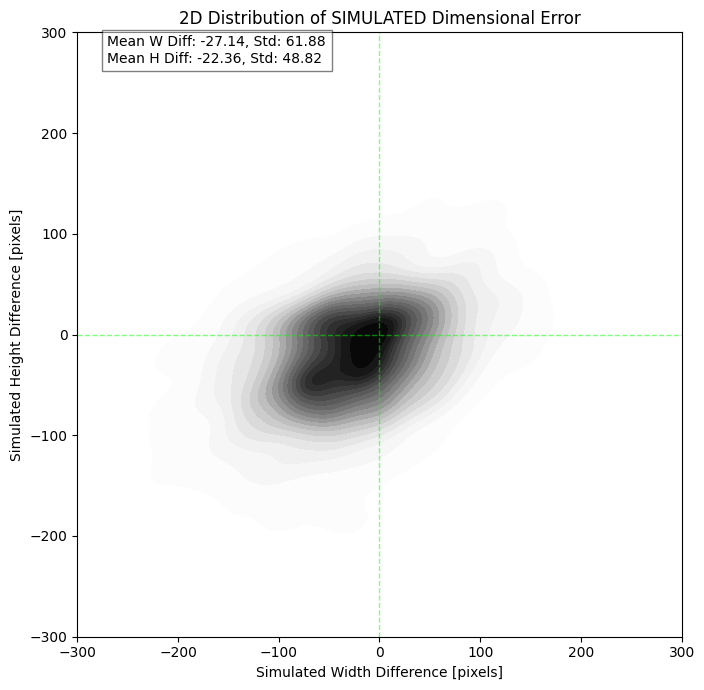

Real Mean W Diff: -24.04, Sim Mean W Diff: -27.14
Real Std W Diff: 72.02, Sim Std W Diff: 61.88
Real Mean H Diff: -20.71, Sim Mean H Diff: -22.36
Real Std H Diff: 53.41, Sim Std H Diff: 48.82


In [50]:
# Verification: Simulate perturbations using the fitted 2D Gaussian (NO SHIFT)
sim_w_diffs = []
sim_h_diffs = []

print(f"Simulating using 2D Gaussian Covariance (Shift = 0)")

# Generate random samples for dimensional differences based on the fitted distribution
# We generate as many samples as we have valid data points to match the dataset size
num_samples = len(width_diffs)
# mean and cov were calculated in the previous cell
sim_dim_diffs = np.random.multivariate_normal(mean, cov, num_samples)

# We iterate through the data to apply these perturbations to the actual finalRects
# This ensures we respect frame boundaries (clipping) which might skew the final distribution
valid_count = 0
idx = 0

for stats in filtered_stats:
    if "rects" in stats:
        rounds_data = stats["rects"]
    else:
        rounds_data = stats["rounds"]

    for r in rounds_data:
        if "finalRect" not in r:
            continue
            
        final = r["finalRect"]
        w_f, h_f = get_wh(final)
        c_fx, c_fy = get_center(final)
        
        if w_f == 0 or h_f == 0:
            continue
            
        if idx >= num_samples:
            break

        # Get the sampled dimensional difference
        dw, dh = sim_dim_diffs[idx]
        idx += 1
        
        # Calculate target initial width/height
        w_new = w_f + dw
        h_new = h_f + dh
        
        # Ensure minimum size (1 pixel)
        w_new = max(1, w_new)
        h_new = max(1, h_new)
        
        # No Shift (dx=0, dy=0) to isolate scaling errors
        dx = 0
        dy = 0
        
        c_px = c_fx + dx
        c_py = c_fy + dy
        
        # Reconstruct coordinates
        x1 = c_px - w_new / 2
        x2 = c_px + w_new / 2
        y1 = c_py - h_new / 2
        y2 = c_py + h_new / 2
        
        # Clip to frame boundaries
        x1 = max(0, min(frame_width, x1))
        x2 = max(0, min(frame_width, x2))
        y1 = max(0, min(frame_height, y1))
        y2 = max(0, min(frame_height, y2))
        
        # Calculate 'simulated' initial width/height from the clipped rect
        w_sim = abs(x2 - x1)
        h_sim = abs(y2 - y1)
        
        # Ignore invalid rects (if they got clipped to nothing)
        if w_sim <= 0 or h_sim <= 0:
            continue

        # Record the difference (Simulated - Final)
        sim_w_diffs.append(w_sim - w_f)
        sim_h_diffs.append(h_sim - h_f)
        valid_count += 1

print(f"Generated {valid_count} simulated samples.")

# 1. Plot Comparison Histograms (1D)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width Differences
sns.histplot(width_diffs, kde=True, ax=axes[0], stat="density", label='Original Data', color='blue', alpha=0.3, element="step")
sns.histplot(sim_w_diffs, kde=True, ax=axes[0], stat="density", label='Simulation (No Shift)', color='orange', alpha=0.3, element="step")
axes[0].set_title('Width Difference Distribution (No Shift)')
axes[0].set_xlabel('Width Difference (Initial - Final)')
axes[0].legend()
axes[0].set_xlim(-limit, limit)

# Height Differences
sns.histplot(height_diffs, kde=True, ax=axes[1], stat="density", label='Original Data', color='blue', alpha=0.3, element="step")
sns.histplot(sim_h_diffs, kde=True, ax=axes[1], stat="density", label='Simulation (No Shift)', color='orange', alpha=0.3, element="step")
axes[1].set_title('Height Difference Distribution (No Shift)')
axes[1].set_xlabel('Height Difference (Initial - Final)')
axes[1].legend()
axes[1].set_xlim(-limit, limit)

plt.tight_layout()
plt.show()

# 2. Plot 2D Distribution of SIMULATED Dimensional Differences (Heatmap)
fig2, ax2 = plt.subplots(figsize=(8, 7))

# Create a 2D density plot (KDE)
sns.kdeplot(x=sim_w_diffs, y=sim_h_diffs, fill=True, cmap="Greys", thresh=0.01, levels=20, ax=ax2)

# Add (0,0) marker (perfect dimensions)
ax2.axhline(0, color='lime', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(0, color='lime', linestyle='--', alpha=0.5, linewidth=1)

ax2.set_title("2D Distribution of SIMULATED Dimensional Error")
ax2.set_xlabel("Simulated Width Difference [pixels]")
ax2.set_ylabel("Simulated Height Difference [pixels]")
ax2.set_aspect('equal')
ax2.set_xlim(-limit, limit)
ax2.set_ylim(-limit, limit)

# Add text for stats
ax2.text(0.05, 0.95, f"Mean W Diff: {np.mean(sim_w_diffs):.2f}, Std: {np.std(sim_w_diffs):.2f}\nMean H Diff: {np.mean(sim_h_diffs):.2f}, Std: {np.std(sim_h_diffs):.2f}", 
        transform=ax2.transAxes, color='black', 
        bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

# Optional: Print stats comparison
print(f"Real Mean W Diff: {np.mean(width_diffs):.2f}, Sim Mean W Diff: {np.mean(sim_w_diffs):.2f}")
print(f"Real Std W Diff: {np.std(width_diffs):.2f}, Sim Std W Diff: {np.std(sim_w_diffs):.2f}")
print(f"Real Mean H Diff: {np.mean(height_diffs):.2f}, Sim Mean H Diff: {np.mean(sim_h_diffs):.2f}")
print(f"Real Std H Diff: {np.std(height_diffs):.2f}, Sim Std H Diff: {np.std(sim_h_diffs):.2f}")